In [27]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time as timer

pd.set_option("display.max_columns", 40)
os.makedirs("figures/model/regression", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
station_day_df = pd.read_parquet("./data/processed/road_station_day_dataset.parquet")
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

print(f"Loaded: {len(station_day_df):,} station-day rows")
print(f"Unique stations: {station_day_df['station_name'].nunique():,}")
print(f"Date range: {station_day_df['planned_date'].min().date()} — {station_day_df['planned_date'].max().date()}")
print(f"\nTarget column: mean_delay_minutes")
print(station_day_df["mean_delay_minutes"].describe().round(3))

Loaded: 33,941 station-day rows
Unique stations: 2,506
Date range: 2026-04-03 — 2026-04-28

Target column: mean_delay_minutes
count    33941.000
mean         0.921
std          2.634
min         -8.000
25%         -0.375
50%          0.300
75%          1.500
max         22.500
Name: mean_delay_minutes, dtype: float64


In [29]:
# Same cap as station_modelling to ensure consistency between models
P99_DURATION = station_day_df["max_effective_duration_hours"].quantile(0.99)
station_day_df["max_effective_duration_hours"] = station_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
station_day_df["mean_effective_duration_hours"] = station_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

print(f"Duration capped at 99th percentile: {P99_DURATION:.1f} hours")

Duration capped at 99th percentile: 456.0 hours


Raw delay range:        [-8.00, 22.50]
winsorised delay range: [-4.00, 11.50]
Skewness after:         2.083


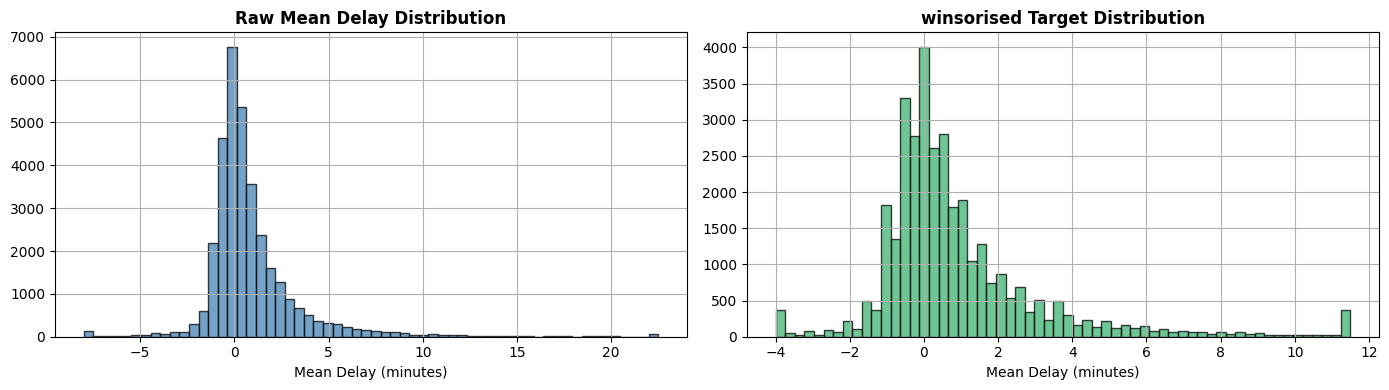

In [30]:
# Winsorise mean_delay_minutes at 1st/99th percentile
# Prevents a handful of extreme station-days from dominating regression loss
delay = station_day_df["mean_delay_minutes"]
P01_DELAY = delay.quantile(0.01)
P99_DELAY = delay.quantile(0.99)

station_day_df["delay_target"] = delay.clip(lower=P01_DELAY, upper=P99_DELAY)

print(f"Raw delay range:        [{delay.min():.2f}, {delay.max():.2f}]")
print(f"winsorised delay range: [{P01_DELAY:.2f}, {P99_DELAY:.2f}]")
print(f"Skewness after:         {station_day_df['delay_target'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
delay.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].set_title("Raw Mean Delay Distribution", fontweight="bold")
axes[0].set_xlabel("Mean Delay (minutes)")

station_day_df["delay_target"].hist(
    bins=60, ax=axes[1], edgecolor="black", alpha=0.75, color="mediumseagreen"
)
axes[1].set_title("winsorised Target Distribution", fontweight="bold")
axes[1].set_xlabel("Mean Delay (minutes)")

plt.tight_layout()
plt.savefig("figures/model/regression/target_distribution.png",
            dpi=200, bbox_inches="tight")
plt.show()

In [31]:
# Identical to station_modelling to ensure both models
# use the same inputs — critical for the Gradio app
# which constructs a single feature vector for both

FEATURES = [
    # Closure presence and severity
    "has_road_closure",
    "road_closure_count",
    "n_unplanned_closures",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    "total_closure_severity",
    "max_road_class",
    # Lag features
    "closures_lag1d",
    "closures_lag3d",
    "closures_lag7d",
    # Temporal features
    "day_of_week",
    "is_weekend",
    "is_monday",
    "is_friday",
    # Service volume
    "train_movements",
]
TARGET = "delay_target"

missing = [f for f in FEATURES if f not in station_day_df.columns]
if missing:
    print(f"WARNING — missing features (re-run eda_05_01): {missing}")
else:
    print(f"All {len(FEATURES)} features present.")

print(f"\nFeatures: {FEATURES}")

All 18 features present.

Features: ['has_road_closure', 'road_closure_count', 'n_unplanned_closures', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'train_movements']


## Temporal Train/Test Split

In [32]:
df_model = (
    station_day_df[FEATURES + [TARGET, "planned_date", "station_name"]]
    .dropna(subset=FEATURES + [TARGET])
    .sort_values("planned_date")
    .reset_index(drop=True)
)

split_idx = int(len(df_model) * 0.8)
train_df  = df_model.iloc[:split_idx]
test_df   = df_model.iloc[split_idx:]

X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print(f"Train: {len(X_train):,} rows | "
      f"{train_df['planned_date'].min().date()} — "
      f"{train_df['planned_date'].max().date()}")
print(f"  Mean delay: {y_train.mean():.3f} min")
print()
print(f"Test:  {len(X_test):,} rows  | "
      f"{test_df['planned_date'].min().date()} — "
      f"{test_df['planned_date'].max().date()}")
print(f"  Mean delay: {y_test.mean():.3f} min")

Train: 27,152 rows | 2026-04-03 — 2026-04-25
  Mean delay: 0.884 min

Test:  6,789 rows  | 2026-04-25 — 2026-04-28
  Mean delay: 0.934 min


In [33]:
from sklearn.dummy        import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble     import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics      import (
    mean_absolute_error, mean_squared_error,
    r2_score, median_absolute_error,
)
from xgboost import XGBRegressor

neg_target = (y_train < 0).sum()
print(f"Negative delay rows in train: {neg_target:,} ({neg_target/len(y_train)*100:.1f}%)")
print("Note: negative = trains arriving early — valid target values")

models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42, verbosity=0,
    ),
    "XGBoost_tuned": XGBRegressor(
        n_estimators=500, learning_rate=0.02, max_depth=3,
        subsample=0.7, colsample_bytree=0.7,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=42, verbosity=0,
    ),
}

try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        random_state=42, verbose=-1,
    )
    print("LightGBM available — included.")
except ImportError:
    print("LightGBM not installed — skipped.")

print(f"\nModels: {list(models.keys())}")

Negative delay rows in train: 9,638 (35.5%)
Note: negative = trains arriving early — valid target values
LightGBM available — included.

Models: ['Dummy (mean)', 'Ridge', 'GradientBoosting', 'XGBoost', 'XGBoost_tuned', 'LightGBM']


In [34]:
results = []

for name, model_obj in models.items():
    t0 = timer.time()
    model_obj.fit(X_train, y_train)
    elapsed = timer.time() - t0

    y_pred = model_obj.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    mdae   = median_absolute_error(y_test, y_pred)

    results.append({
        "model":     name,
        "MAE":       round(mae, 4),
        "RMSE":      round(rmse, 4),
        "R2":        round(r2, 4),
        "MedianAE":  round(mdae, 4),
        "train_sec": round(elapsed, 2),
        "_model":    model_obj,
        "_y_pred":   y_pred,
    })
    print(f"{name:<20} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

dummy_mae = results_df[results_df["model"] == "Dummy (mean)"]["MAE"].values[0]
best_mae  = results_df.iloc[0]["MAE"]

print()
display(results_df[["model", "MAE", "RMSE", "R2", "MedianAE", "train_sec"]])
print(f"\nDummy baseline MAE:        {dummy_mae:.4f} min")
print(f"Best model MAE:            {best_mae:.4f} min")
print(f"Improvement over baseline: {dummy_mae - best_mae:.4f} min")

Dummy (mean)         MAE=1.4020  RMSE=2.1076  R²=-0.0005  (0.0s)
Ridge                MAE=1.3751  RMSE=2.1066  R²=0.0005  (0.0s)
GradientBoosting     MAE=1.3658  RMSE=2.1055  R²=0.0015  (11.9s)
XGBoost              MAE=1.3667  RMSE=2.1077  R²=-0.0007  (0.3s)
XGBoost_tuned        MAE=1.3652  RMSE=2.1026  R²=0.0043  (0.4s)
LightGBM             MAE=1.3686  RMSE=2.1055  R²=0.0015  (0.2s)



,model,MAE,RMSE,R2,MedianAE,train_sec
0,XGBoost_tuned,1.3652,2.1026,0.0043,0.9283,0.45
1,GradientBoosting,1.3658,2.1055,0.0015,0.9245,11.89
2,XGBoost,1.3667,2.1077,-0.0007,0.9258,0.32
3,LightGBM,1.3686,2.1055,0.0015,0.9267,0.17
4,Ridge,1.3751,2.1066,0.0005,0.9385,0.01
5,Dummy (mean),1.4020,2.1076,-0.0005,0.9678,0.00



Dummy baseline MAE:        1.4020 min
Best model MAE:            1.3652 min
Improvement over baseline: 0.0368 min


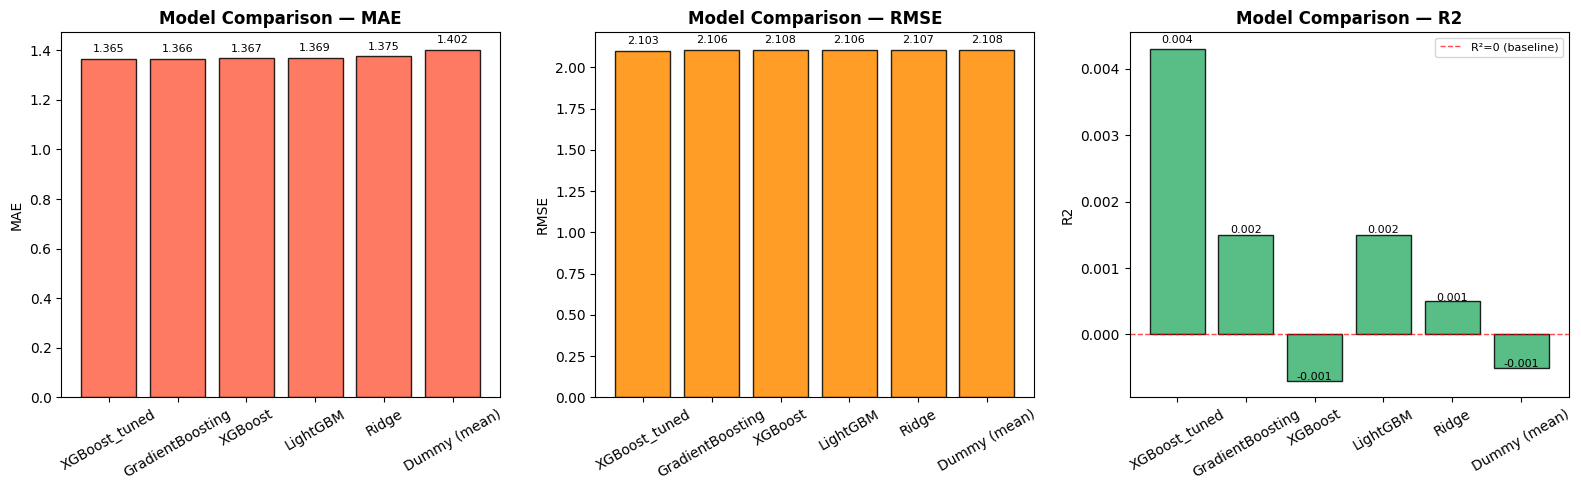

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in [
    (axes[0], "MAE",  "tomato"),
    (axes[1], "RMSE", "darkorange"),
    (axes[2], "R2",   "mediumseagreen"),
]:
    ax.bar(results_df["model"], results_df[metric],
           color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + abs(v) * 0.02, f"{v:.3f}",
                ha="center", fontsize=8)
    if metric == "R2":
        ax.axhline(0, color="red", linestyle="--", lw=1,
                   alpha=0.7, label="R²=0 (baseline)")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/model/regression/model_comparison.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Actual vs Predicted (Best Model)

Best model: XGBoost_tuned  MAE=1.3652  R²=0.0043


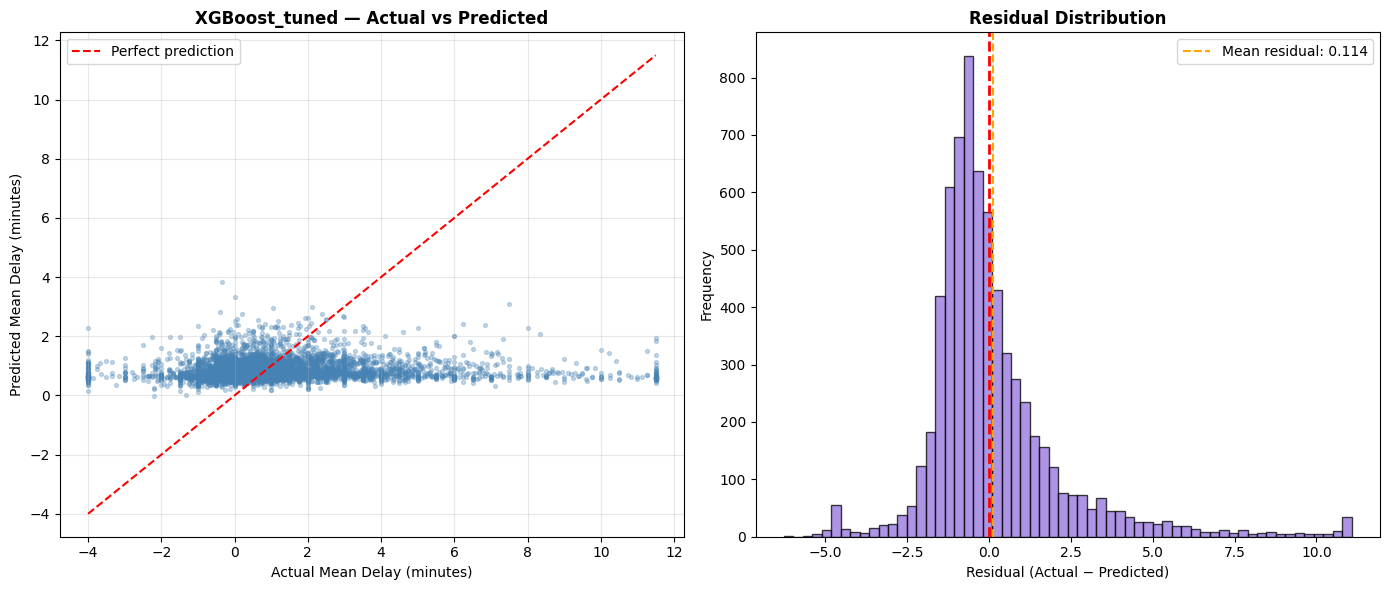

Residual mean:  0.1137
Residual std:   2.0995


In [36]:
best_row   = results_df.iloc[0]
best_model = best_row["_model"]
best_name  = best_row["model"]
best_preds = best_row["_y_pred"]

print(f"Best model: {best_name}  MAE={best_row['MAE']:.4f}  R²={best_row['R2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=8, color="steelblue")
lim = [min(y_test.min(), best_preds.min()),
       max(y_test.max(), best_preds.max())]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Mean Delay (minutes)")
axes[0].set_ylabel("Predicted Mean Delay (minutes)")
axes[0].set_title(f"{best_name} — Actual vs Predicted", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=60, edgecolor="black", alpha=0.75, color="mediumpurple")
axes[1].axvline(0, color="red", linestyle="--", lw=2)
axes[1].axvline(residuals.mean(), color="orange", linestyle="--", lw=1.5,
                label=f"Mean residual: {residuals.mean():.3f}")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/model/regression/actual_vs_predicted.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"Residual mean:  {residuals.mean():.4f}")
print(f"Residual std:   {residuals.std():.4f}")

## Feature Importance

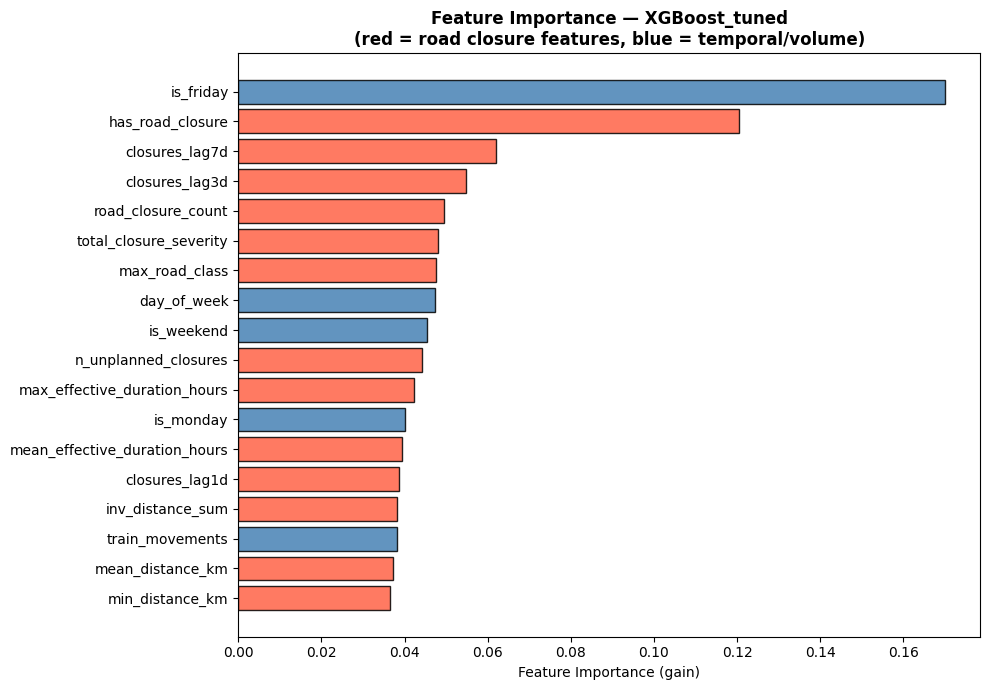

Feature importance ranked:
                      feature  importance
                    is_friday    0.169953
             has_road_closure    0.120582
               closures_lag7d    0.061914
               closures_lag3d    0.054735
           road_closure_count    0.049538
       total_closure_severity    0.048148
               max_road_class    0.047663
                  day_of_week    0.047347
                   is_weekend    0.045314
         n_unplanned_closures    0.044126
 max_effective_duration_hours    0.042292
                    is_monday    0.040196
mean_effective_duration_hours    0.039340
               closures_lag1d    0.038746
             inv_distance_sum    0.038226
              train_movements    0.038182
             mean_distance_km    0.037181
              min_distance_km    0.036514


In [37]:
if hasattr(best_model, "feature_importances_"):
    imp_df = (
        pd.DataFrame({
            "feature":    FEATURES,
            "importance": best_model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    road_features = {
        "has_road_closure", "road_closure_count", "n_unplanned_closures",
        "min_distance_km", "mean_distance_km", "max_effective_duration_hours",
        "mean_effective_duration_hours", "inv_distance_sum",
        "total_closure_severity", "max_road_class",
        "closures_lag1d", "closures_lag3d", "closures_lag7d",
    }
    colors = [
        "tomato" if f in road_features else "steelblue"
        for f in imp_df["feature"]
    ]

    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["importance"],
             color=colors, edgecolor="black", alpha=0.85)
    plt.xlabel("Feature Importance (gain)")
    plt.title(
        f"Feature Importance — {best_name}\n"
        "(red = road closure features, blue = temporal/volume)",
        fontweight="bold"
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/model/regression/feature_importance.png",
                dpi=200, bbox_inches="tight")
    plt.show()

    print("Feature importance ranked:")
    print(imp_df.to_string(index=False))

elif hasattr(best_model, "coef_"):
    imp_df = (
        pd.DataFrame({
            "feature":     FEATURES,
            "coefficient": best_model.coef_
        })
        .sort_values("coefficient", key=abs, ascending=False)
    )
    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["coefficient"],
             color="cadetblue", edgecolor="black", alpha=0.85)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Coefficient")
    plt.title(f"Feature Coefficients — {best_name}", fontweight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/model/regression/feature_importance.png",
                dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)

## Forward Prediction on Timetable

In [38]:
timetable_df = pd.read_parquet(
    "./data/processed/road_timetable_station_day.parquet"
)
timetable_df["planned_date"] = pd.to_datetime(timetable_df["planned_date"])

# Apply same caps as training
timetable_df["max_effective_duration_hours"] = timetable_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
timetable_df["mean_effective_duration_hours"] = timetable_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

missing_inf = [f for f in FEATURES if f not in timetable_df.columns]
if missing_inf:
    print(f"WARNING — missing features: {missing_inf}")
else:
    print(f"All {len(FEATURES)} features present in timetable dataset.")

X_future = timetable_df[FEATURES].fillna(0)
timetable_df["predicted_delay_minutes"] = best_model.predict(X_future)

print(f"\nTimetable dataset: {len(timetable_df):,} rows")
print("Predicted delay statistics:")
print(timetable_df["predicted_delay_minutes"].describe().round(3))

# Top predicted high-delay station-days
id_cols   = [c for c in ["planned_date", "station_name", "station_code"]
             if c in timetable_df.columns]
show_cols = id_cols + [
    "predicted_delay_minutes", "has_road_closure",
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "is_friday"
]
show_cols = [c for c in show_cols if c in timetable_df.columns]

print("\nTop 15 station-days by predicted delay:")
display(
    timetable_df
    .sort_values("predicted_delay_minutes", ascending=False)
    .head(15)[show_cols]
    .reset_index(drop=True)
)

timetable_df.to_parquet(
    "./data/processed/road_timetable_station_day.parquet", index=False
)
print("\nSaved predictions back to road_timetable_station_day.parquet")
print("New column: predicted_delay_minutes")

All 18 features present in timetable dataset.

Timetable dataset: 51,437 rows
Predicted delay statistics:
count    51437.000
mean         1.122
std          0.425
min          0.099
25%          0.851
50%          0.980
75%          1.318
max          5.970
Name: predicted_delay_minutes, dtype: float64

Top 15 station-days by predicted delay:


,planned_date,station_name,station_code,predicted_delay_minutes,has_road_closure,road_closure_count,n_unplanned_closures,min_distance_km,is_friday
0,2026-04-17,Alderley Edge,ALD,5.969635,1.0,11.0,5.0,11.051002,1
1,2026-04-17,Davenport,DVN,5.570467,1.0,11.0,6.0,12.129236,1
2,2026-04-17,Bramhall,BML,5.547602,1.0,12.0,6.0,11.029731,1
3,2026-04-17,Smithy Bridge,SMB,5.439136,1.0,10.0,3.0,12.286724,1
4,2026-04-17,Bolton,BON,5.294596,1.0,13.0,5.0,10.254693,1
5,2026-04-17,Heald Green,HDG,5.290612,1.0,11.0,5.0,12.296569,1
6,2026-04-17,Manchester Airport,MIA,5.257565,1.0,11.0,5.0,14.246643,1
7,2026-04-24,Alderley Edge,ALD,5.202034,1.0,12.0,6.0,12.745488,1
8,2026-04-17,Wilmslow,WML,5.176873,1.0,13.0,7.0,10.476673,1
9,2026-04-24,Smithy Bridge,SMB,5.171700,1.0,11.0,4.0,12.286724,1



Saved predictions back to road_timetable_station_day.parquet
New column: predicted_delay_minutes


In [39]:
regression_model_path = "models/road_rail_regression_model.pkl"

meta = {
    "model_name":         best_name,
    "features":           FEATURES,
    "target":             "mean_delay_minutes",
    "delay_winsorise_p01": float(P01_DELAY),
    "delay_winsorise_p99": float(P99_DELAY),
    "duration_cap_hours": float(P99_DURATION),
    "mae":                float(best_row["MAE"]),
    "rmse":               float(best_row["RMSE"]),
    "r2":                 float(best_row["R2"]),
    "train_rows":         int(len(X_train)),
    "test_rows":          int(len(X_test)),
}

joblib.dump({"model": best_model, "meta": meta}, regression_model_path)

print(f"Saved: {regression_model_path}")
print(json.dumps(
    {k: v for k, v in meta.items() if k != "features"}, indent=2
))

Saved: models/road_rail_regression_model.pkl
{
  "model_name": "XGBoost_tuned",
  "target": "mean_delay_minutes",
  "delay_winsorise_p01": -4.0,
  "delay_winsorise_p99": 11.5,
  "duration_cap_hours": 455.9997222222222,
  "mae": 1.3652,
  "rmse": 2.1026,
  "r2": 0.0043,
  "train_rows": 27152,
  "test_rows": 6789
}
